## import all lib

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
print("All necessary libraries have been imported successfully.")



All necessary libraries have been imported successfully.


In [3]:
df=pd.read_csv('datasets/kidney_disease_cleaned.csv')

In [4]:
df.head(4)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,urine_abnormality,urine_protein_score,renal_function_avg,renal_function_load,electrolyte_gap,hemo_pcv_ratio,wbc_rc_ratio,age_bp_interaction,comorbidity_flag,senior_age_flag
0,60.0,90.0,1.015,3.0,0.0,0.0,1.0,0.0,0.0,74.0,...,1,3.0,33.366667,27.5,138.8,2.033333,11.666667,5400.0,1,1
1,76.0,70.0,1.015,1.0,0.0,0.0,1.0,0.0,0.0,92.0,...,1,1.0,40.933333,52.2,129.1,10.300000,2.454545,5320.0,1,1
2,48.0,70.0,1.015,0.0,0.0,0.0,1.0,0.0,0.0,124.0,...,0,0.0,49.733333,28.8,137.8,2.480000,3.666667,3360.0,1,0
3,15.0,60.0,1.020,3.0,0.0,0.0,1.0,0.0,0.0,86.0,...,1,3.0,33.866667,9.0,134.0,5.500000,NaN,900.0,1,0


In [5]:
df.isnull().sum()

age                    0
bp                     0
sg                     0
al                     0
su                     0
rbc                    0
pc                     0
pcc                    0
ba                     0
bgr                    0
bu                     0
sc                     0
sod                    0
pot                    0
hemo                   0
pcv                    0
wc                     0
rc                     0
htn                    0
dm                     0
cad                    0
appet                  0
pe                     0
ane                    0
classification         0
urine_abnormality      0
urine_protein_score    0
renal_function_avg     0
renal_function_load    0
electrolyte_gap        0
hemo_pcv_ratio         1
wbc_rc_ratio           1
age_bp_interaction     0
comorbidity_flag       0
senior_age_flag        0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
X=df.drop('classification',axis=1)
y=df['classification']

In [8]:
X.shape,y.shape

((137, 34), (137,))

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
st=StandardScaler()
X_train=st.fit_transform(X_train)
X_test=st.transform(X_test)

In [11]:
from sklearn.metrics import accuracy_score, classification_report

models = [
    ("Logistic Regression", LogisticRegression(max_iter=500)),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("Random Forest", RandomForestClassifier(random_state=42)),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=42)),
    ("AdaBoost", AdaBoostClassifier(random_state=42)),
    ("SVC", SVC(random_state=42)),
    ("KNN", KNeighborsClassifier()),
    ("Gaussian NB", GaussianNB()),
    ("Bernoulli NB", BernoulliNB()),
    ("Multinomial NB", MultinomialNB()),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis()),
    ("MLP", MLPClassifier(max_iter=500, random_state=42))
]

for name, model in models:
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"=== {name} ===")
        print(f"Accuracy: {acc:.4f}")
        print(classification_report(y_test, y_pred, zero_division=0))
    except Exception as e:
        print(f"{name} failed: {e}")

=== Logistic Regression ===
Accuracy: 0.9643
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.96      1.00      0.98        27

    accuracy                           0.96        28
   macro avg       0.48      0.50      0.49        28
weighted avg       0.93      0.96      0.95        28

=== Decision Tree ===
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00        27

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28

=== Random Forest ===
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00        27

    accuracy                           1.00        28
   ma

Multinomial NB failed: Negative values in data passed to MultinomialNB (input X).
QDA failed: The covariance matrix of class 0 is not full rank. When using `solver='svd'` the number of samples in each class should be more than the number of features, but class 0 has 9 samples and 34 features. Try using `solver='eigen'` and setting the parameter `shrinkage` for regularization.
Best model: Decision Tree with accuracy 1.0000


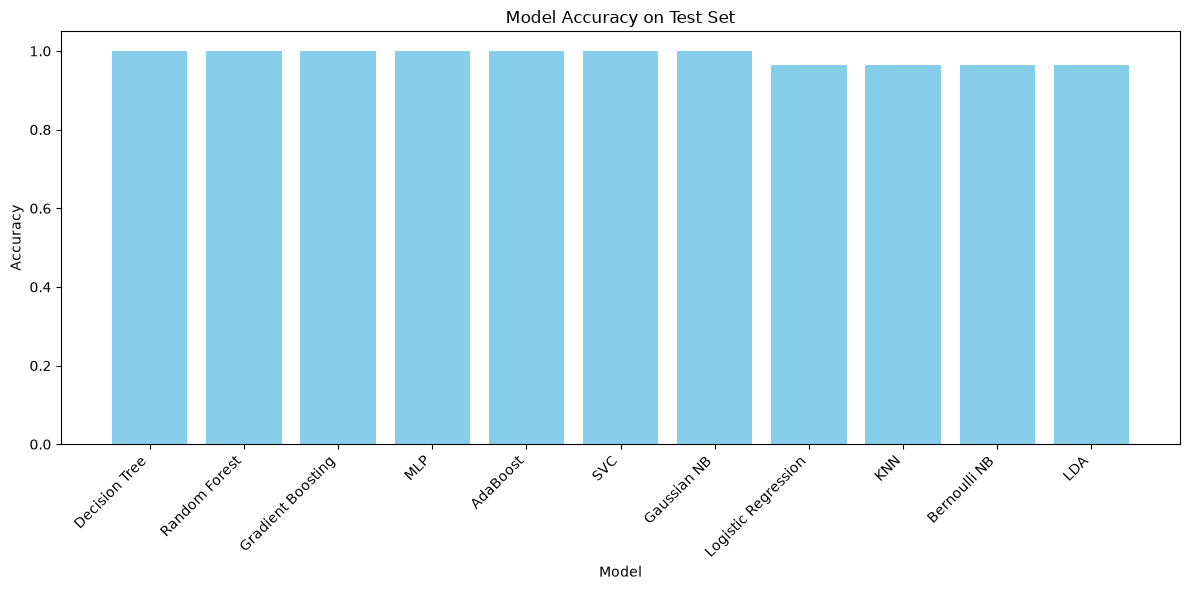

In [12]:
import matplotlib.pyplot as plt

accuracies = []
for name, model in models:
    try:
        model.fit(X_train, y_train)
        y_pred_model = model.predict(X_test)
        acc_model = accuracy_score(y_test, y_pred_model)
        accuracies.append((name, acc_model))
    except Exception as e:
        accuracies.append((name, np.nan))
        print(f"{name} failed: {e}")

best_name, best_acc = max(accuracies, key=lambda item: item[1] if not np.isnan(item[1]) else -1)
best_model = next(m for n, m in models if n == best_name)
best_model.fit(X_train, y_train)

print(f"Best model: {best_name} with accuracy {best_acc:.4f}")

acc_df = pd.DataFrame(accuracies, columns=["model", "accuracy"]).sort_values("accuracy", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(acc_df["model"], acc_df["accuracy"], color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.title("Model Accuracy on Test Set")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.tight_layout()
plt.tight_layout()
plt.savefig('output/All models.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

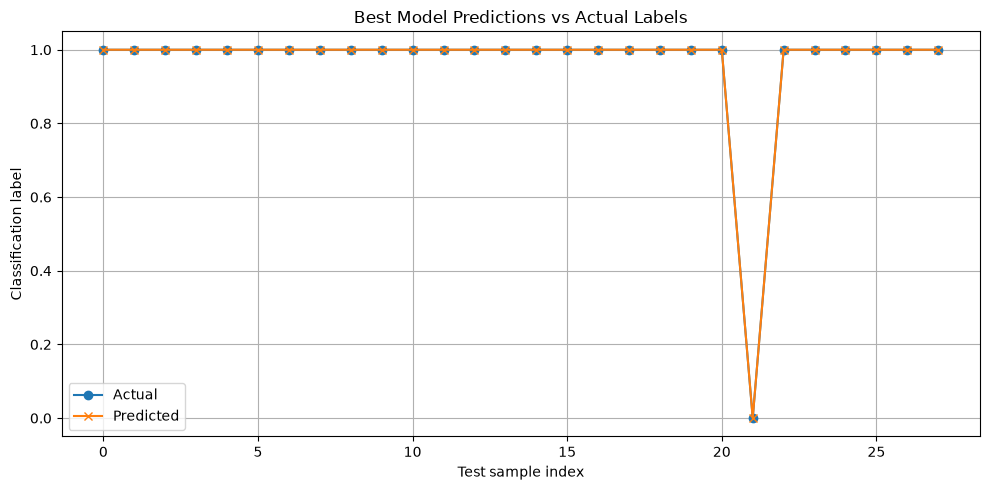

In [15]:
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 5))
plt.plot(range(len(y_test)), y_test.reset_index(drop=True), label="Actual", marker="o")
plt.plot(range(len(y_pred_best)), y_pred_best, label="Predicted", marker="x")
plt.title("Best Model Predictions vs Actual Labels")
plt.xlabel("Test sample index")
plt.ylabel("Classification label")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('output/best_model_predictions.png',
            dpi=150,
            bbox_inches='tight')
plt.tight_layout()
plt.show()